In [1]:
import sys
from pathlib import Path

_root = Path.cwd()  # assumes notebook is run from the project root
sys.path.insert(0, str(_root / 'MiniNepGrid_Scripts'))
sys.path.insert(0, str(_root / 'ReflectedSpectra_Scripts'))

import matplotlib.pyplot as plt
import numpy as np
import h5py
import copy
import pandas as pd
from scipy import optimize
from matplotlib import pyplot as plt
import pickle
from itertools import cycle
import matplotlib.colors as mcolors
import astropy.units as u
import astropy.constants as const
import heapq

from photochem.utils import stars
import PICASO_Climate_grid_121625 as picaso_grid
import Photochem_grid_121625 as Photochem_grid
import Reflected_Spectra_grid_13026 as Reflected_Spectra
from picaso.photochem import EquilibriumChemistry
import GraphsKey

import os
from pathlib import Path
from cycler import cycler

current_directory = Path.cwd()
references_directory_path = "Installation_Setup_Instructions/picasofiles/reference"
PYSYN_directory_path = "Installation_Setup_Instructions/picasofiles/grp/redcat/trds"
print(os.path.join(current_directory, references_directory_path))
print(os.path.join(current_directory, PYSYN_directory_path))

os.environ['picaso_refdata']= os.path.join(current_directory, references_directory_path)
os.environ['PYSYN_CDBS']= os.path.join(current_directory, PYSYN_directory_path)


import picaso.justdoit as jdi
import picaso.justplotit as jpi

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/grp/redcat/trds
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/grp/redcat/trds
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference/opacities/opacities_photochem_0.1_250.0_R15000_v2.db
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/grp/redcat/trds


In [5]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("data/RLS_results/RLS_O2Rich_MiniNep_noO2_cld0.5.pkl", "rb") as f:
    old = pickle.load(f)   # subneptune_picaso_updated

with open("data/RLS_results/RLS_O2Rich_MiniNep_nbtest_noO2_cld0.5.pkl", "rb") as f:
    new = pickle.load(f)   # subneptune_nb_picaso (after fluxes_noalloc fix)


In [6]:
old.keys()

dict_keys(['wno', 'fpfs', 'alb', 'clouds', 'df_cld', 'df_cldfree'])

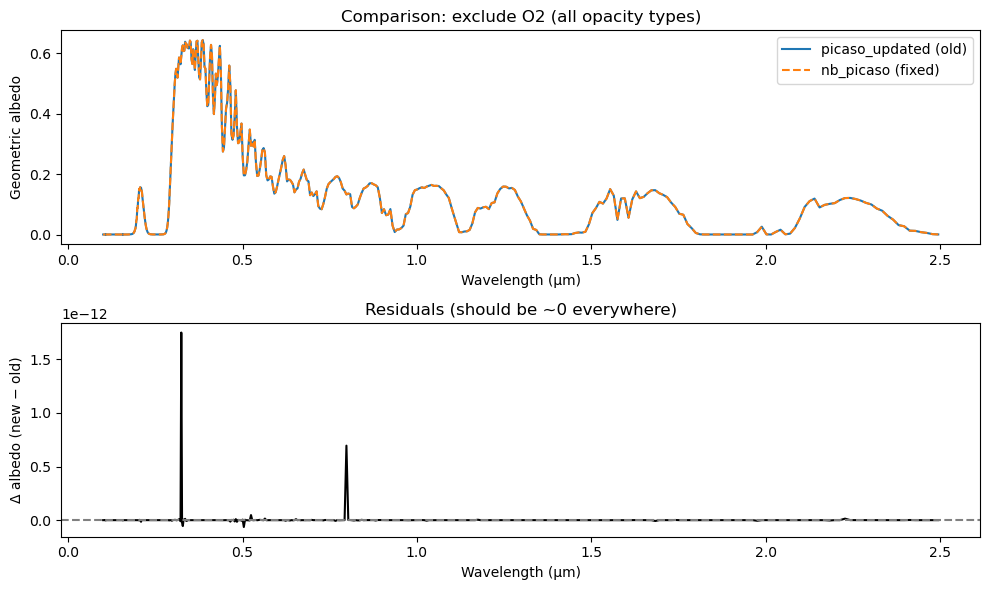

In [8]:
# Check what's inside if unsure of structure:
# print(type(old), old.keys() if hasattr(old, 'keys') else dir(old))

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].plot(1e4/old['wno'], old['alb'], label='picaso_updated (old)')
axes[0].plot(1e4/new['wno'], new['alb'], label='nb_picaso (fixed)', ls='--')
axes[0].set_xlabel('Wavelength (μm)')
axes[0].set_ylabel('Geometric albedo')
axes[0].legend()
axes[0].set_title('Comparison: exclude O2 (all opacity types)')

# Residuals
axes[1].plot(1e4/old['wno'], new['alb'] - old['alb'], color='k')
axes[1].axhline(0, ls='--', color='gray')
axes[1].set_xlabel('Wavelength (μm)')
axes[1].set_ylabel('Δ albedo (new − old)')
axes[1].set_title('Residuals (should be ~0 everywhere)')

plt.tight_layout()
plt.show()